# MNQ (Micro E-mini Nasdaq-100) — MA crossover, Tradovate exchange

Mirrors `MES/step_2_run_full_backtest.ipynb`'s MA-crossover setup, applied to **Micro E-mini Nasdaq-100 futures** (MNQ) instead of MES: real 1h OHLC pulled from this repo's Mongo/Timescale store (via the shared `data_aggregator.mongo_timescale_aggregator` module), whole-contract position sizing, tick-based slippage + per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy**: a single crossover -- the winner of the four-way indicator-family comparison (KAMA, EMA, HMA, DEMA, each fast-line paired against a plain SMA slow line) run in `MNQ/step_1_find_best_indicators_and_parameters.ipynb`, selected by a trade-level Sharpe lower bound rather than raw return (see that notebook's "Methodology" and "Final pick" cells for the full reasoning + honest caveats about how much confidence that pick actually supports). Only 2 indicators feed a single strategy here, run through the full event-driven engine: real order fills, margin, whole-contract sizing, and the drawdown middleware, none of which the vectorized notebook models. Same `DATE_FROM`/`DATE_TO` window as that notebook so the two are comparable. Results here will still differ from the vectorized numbers -- that's expected, not a bug, since whole-contract sizing/margin are modeled for real here instead of as a frictionless percentage-return approximation.

**Costs, now researched** (`PROP_FIRM_PLAN.md`, `OPTIMIZATION_RESEARCH_PLAN.md`): MNQ tick_size=0.25 index points ($0.50/tick, CME spec) and a $0.91/side commission are set directly on `TRADOVATE_FUTURES["MNQ"]` in `exchange_config.py`. MNQ commission: Tradeify charges $1.82 round-turn -> $0.91/side, explicitly confirmed for MNQ (not just inferred by analogy with MES). The drawdown middleware below uses Tradeify's real $50k-Growth-account number (4%, not this middleware's generic 5% default) and models the real lock-once-reached trail-freeze mechanic.

In [1]:
import json
import os

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover/MNQ


In [2]:

# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 1
UNIT_OF_TIME = "hour"

DISPLAY_SYMBOL = "MNQ"       # bare symbol, as registered in Mongo `instruments`
SYMBOL = "MNQ/USD"           # backtester-internal symbol (asset/quote)
SOURCE = "ib"                # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"

# Same window as notebooks/vectorized_backtest_mes_tradovate.ipynb, for comparability.
DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"

# Winner of the 4-indicator-family comparison in step_1 (unlike MES/KAMA or M2K/EMA):
# DEMA(fast)/SMA(slow), long_len=32, short_len=10; see step_1's "Final pick" cell for
# the full reasoning + caveats.
DEMA_FAST_LEN = 10
DEMA_SMA_SLOW = 32

ohlc = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)
ohlc = ohlc.loc[DATE_FROM:DATE_TO]

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

# --- DEMA(fast)/SMA(slow) crossover indicators -- only 2, one per side of the crossover.
DEMA_INDICATOR_NAME = 'dema'
SMA_INDICATOR_NAME = 'sma'
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{DEMA_INDICATOR_NAME}_{DEMA_FAST_LEN}",
    df=Indicators.dema(ohlc, length=DEMA_FAST_LEN)
)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{SMA_INDICATOR_NAME}_{DEMA_SMA_SLOW}",
    df=Indicators.sma(ohlc, DEMA_SMA_SLOW)
)

market.compile()

{Timestamp('2025-07-08 14:45:17.999000'): {'num': 0,
  'time_open': Timestamp('2025-07-08 13:45:18'),
  'time_close': Timestamp('2025-07-08 14:45:17.999000'),
  'MNQ/USD': {'open': 23809.0,
   'high': 23822.25,
   'low': 23775.25,
   'close': 23776.75,
   'volume': 48797.0,
   'indicators': {'dema_10': nan, 'sma_32': nan}}},
 Timestamp('2025-07-08 14:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2025-07-08 14:00:00'),
  'time_close': Timestamp('2025-07-08 14:59:59.999000'),
  'MNQ/USD': {'open': 23777.25,
   'high': 23840.5,
   'low': 23734.75,
   'close': 23790.25,
   'volume': 236908.0,
   'indicators': {'dema_10': nan, 'sma_32': nan}}},
 Timestamp('2025-07-08 15:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2025-07-08 15:00:00'),
  'time_close': Timestamp('2025-07-08 15:59:59.999000'),
  'MNQ/USD': {'open': 23790.0,
   'high': 23811.75,
   'low': 23749.25,
   'close': 23802.75,
   'volume': 118705.0,
   'indicators': {'dema_10': nan, 'sma_32': nan}}},
 Timestamp('2025-

In [3]:

# single DEMA(fast)/SMA(slow) crossover strategy, full weight -- see
# MNQ/step_1_find_best_indicators_and_parameters.ipynb for how these parameters were picked.
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1.0,
        strategy=MaCrossoverStrategy(
            key=f"DEMA_{DEMA_FAST_LEN}_SMA_{DEMA_SMA_SLOW}_MNQ",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{DEMA_INDICATOR_NAME}_{DEMA_FAST_LEN}",
            slow_indicator_key=f"{SMA_INDICATOR_NAME}_{DEMA_SMA_SLOW}",
            sl_percent=0.3,
            tp_percent=0.6,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [4]:

# Tradovate per-symbol config: point value / tick size / min size-step / fees.
# MNQ has a real tick_size and fee_per_contract_override set directly on
# TRADOVATE_FUTURES in exchange_config.py (see PROP_FIRM_PLAN.md for the research).
symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)

# instantiate exchange -- futures, point-value/tick-based math via symbol_config_provider
# (slippage/maker_fee/taker_fee below are unused once symbol_config_provider is set, but
# still required constructor args).
exchange = Exchange(
            market=market,
            slippage=0.0,
            maker_fee=0.0,
            taker_fee=0.0,
            market_type=MarketType.future,
            max_leverage=10,  # NOTE: this system doesn't model Tradovate's real per-symbol
                               # exchange-set margin schedule yet -- max_leverage is a stand-in.
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
        )


In [5]:

# instantiate reporter
# periods_per_year=252: real trading-days/year convention for futures (not 365,
# which is only correct for a 24/7 crypto market -- see PerformanceAnalyzer's own
# docstring). Using the wrong constant here previously inflated every Sharpe/
# Sortino/annualized-volatility number in this pipeline by sqrt(365/252) =~ 1.20
# (~20%) versus the correct figure -- CAGR/Calmar/max_drawdown/net_return are
# unaffected since they don't depend on periods_per_year.
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL],
                    periods_per_year=252)


Candles Processed:  5312
Account failed (drawdown breach):  False
Drawdown floor locked (reached profit buffer):  True


metric,algo,MNQ/USD,description
sharpe_ratio,0.8201,1.3682,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,1.2972,2.0426,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,8.8412,15.2870,How much the equity curve swings per year. Lower = smoother.
cagr_percent,10.4471,33.1033,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,1.2171,2.3996,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,1.0881,2.1240,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-8.5838,-13.7952,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,169,169,How long it took to recover the loss. Shorter is better.
ulcer_index,2.9681,4.0656,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.8078,-1.6038,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


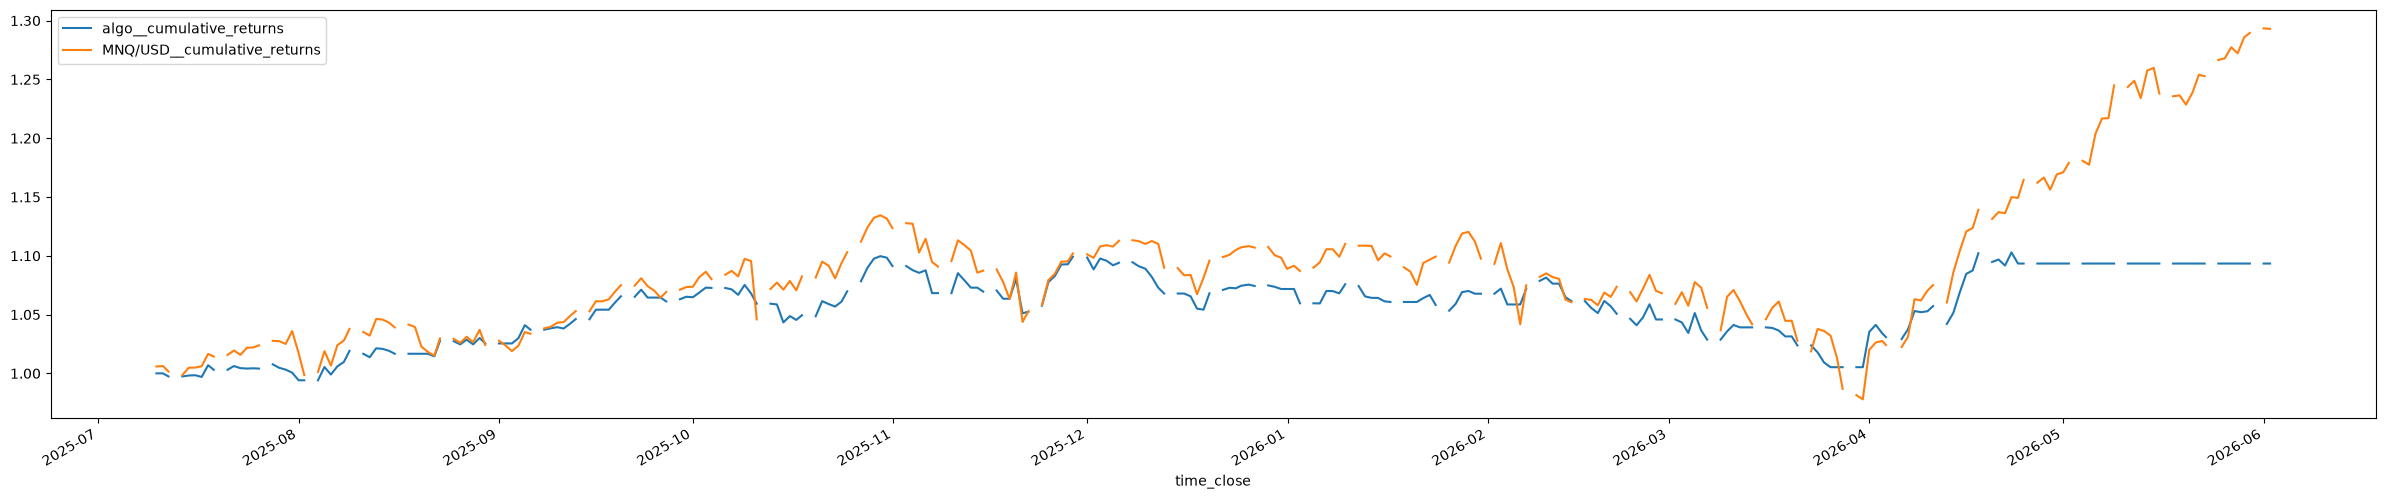

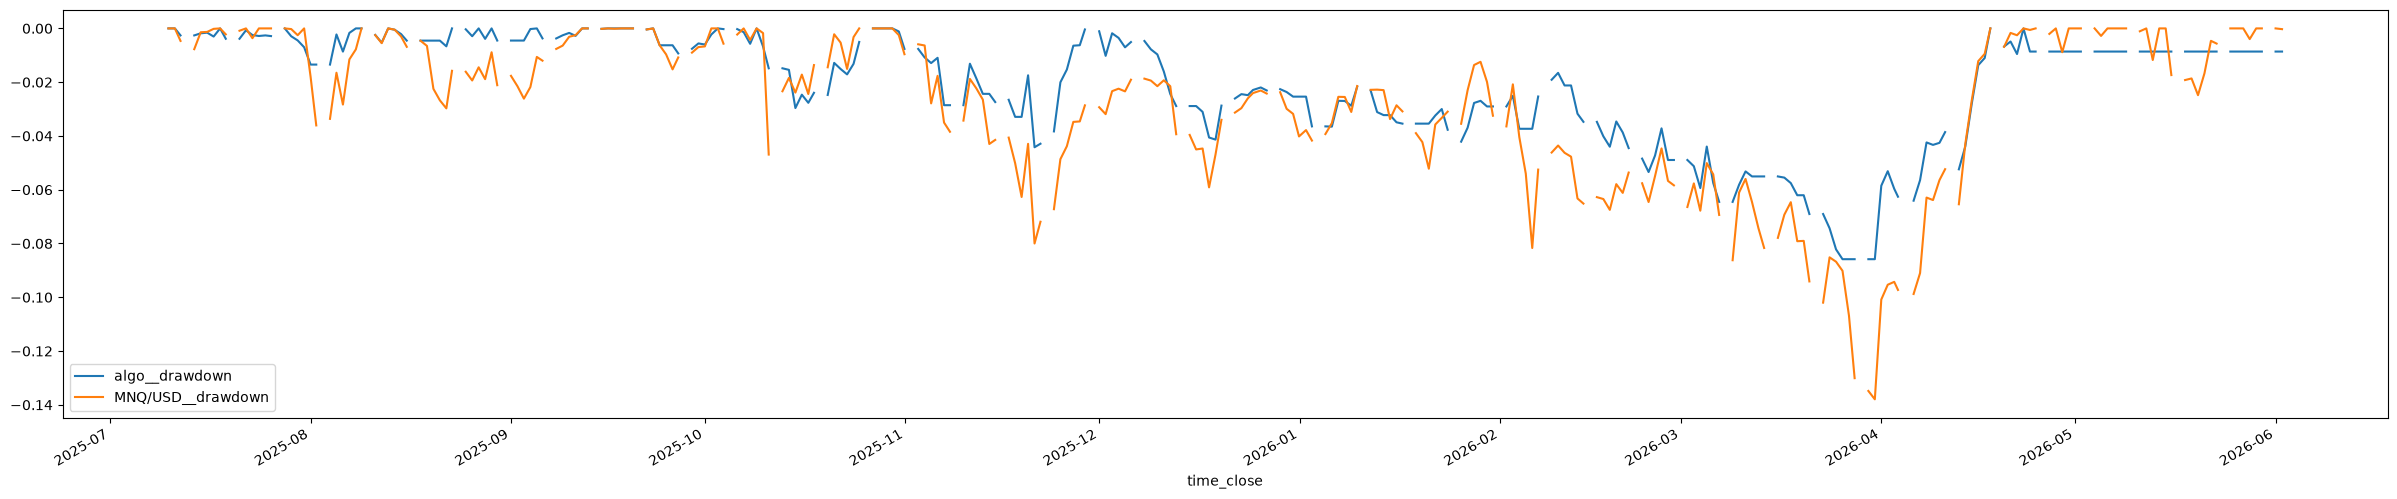

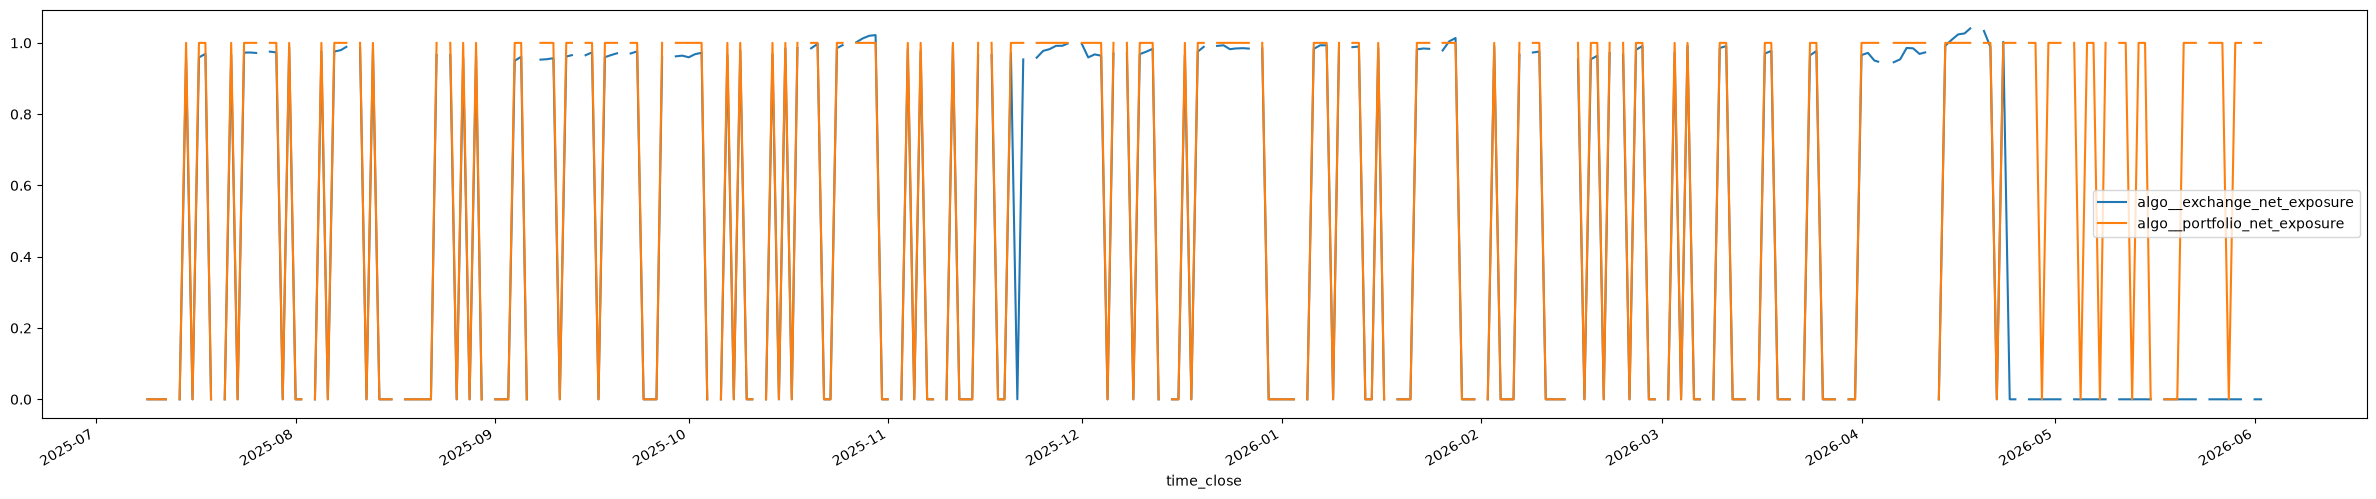

In [6]:

# run only one next step
market.reset()

# Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown, permanently halts
# trading (account_failed) once breached -- see middleware.py / PROP_FIRM_PLAN.md.
# Now also models Tradeify's real lock-once-reached mechanic: the trailing floor
# freezes permanently at initial_balance + $100 the first time EOD balance reaches
# initial_balance * (1 + drawdown_percent) + $100 (e.g. $52,100 for this account),
# rather than continuing to trail upward forever past that point.
drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.04)
# Tradeify's real $1,250/day soft daily-loss pause on a $50k account (2.5% of
# balance): flattens and halts for the rest of the trading day, then resumes
# normally the next day (unlike the drawdown middleware's permanent halt).
# Previously not modeled at all in this pipeline despite being a real,
# already-documented Tradeify rule (PROP_FIRM_PLAN.md).
daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.025)

backtest = Backtester(
    market=market,
    portfolio=portfolio,
    exchange=exchange,
    reporter=reporter,
    middlewares=[daily_loss_middleware, drawdown_middleware],
)
# deposit prop-firm-sized funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Drawdown floor locked (reached profit buffer): ", drawdown_middleware.locked)
# formatted HTML table (description column + color-coded cells) instead of the raw
# numeric DataFrame -- see backtester.performance.report_html for the per-metric rules.
display(HTML(backtest.reporter.summary_html_table()))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [7]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())


,time,message
0,2025-07-08 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2025-07-11 17:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2025-07-11 20:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2025-07-14 14:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2025-07-15 20:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
...,...,...
210,2026-05-26 13:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
211,2026-05-27 16:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
212,2026-05-28 14:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
213,2026-06-01 14:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...


In [8]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,MNQ/USD,long,1752256799999000000,1752267599999000000,23898.50,23834.75,signal,-0.002668,loser,10800000000000,0.3
1,MNQ/USD,long,1752505199999000000,1752613199999000000,23891.75,23918.75,signal,0.001130,winner,108000000000000,0.3
2,MNQ/USD,long,1752695999999000000,1752857999999000000,23977.75,24095.00,signal,0.004890,winner,162000000000000,0.3
3,MNQ/USD,long,1753073999999000000,1753171199999000000,24180.25,24216.50,signal,0.001499,winner,97200000000000,0.3
4,MNQ/USD,long,1753264799999000000,1753279199999000000,24182.50,24072.25,signal,-0.004559,loser,14400000000000,0.3
...,...,...,...,...,...,...,...,...,...,...,...
102,MNQ/USD,long,1778648399999000000,1778817599999000000,29576.50,29856.25,signal,0.009459,winner,169200000000000,0.3
103,MNQ/USD,long,1779109199999000000,1779116399999000000,29699.00,29368.75,signal,-0.011120,loser,7200000000000,0.3
104,MNQ/USD,long,1779263999999000000,1779764399999000000,29314.25,30112.00,signal,0.027214,winner,500400000000000,0.3
105,MNQ/USD,long,1779803999999000000,1779901199999000000,30302.50,30284.25,signal,-0.000602,loser,97200000000000,0.3
